# Segezha Group (SGZH) — финансовый анализ
 
**Дата:** декабрь 2025  
**Источники:** отчётность ПАО «Сегежа Групп» по МСФО, данные Московской биржи

---

## О компании

**Segezha Group** — крупнейший в России вертикально интегрированный лесопромышленный холдинг, контролируемый АФК «Система» (~73%). Компания провела IPO в апреле 2021 года по цене 8 руб./акцию и привлекла 30 млрд руб.

**Ключевые сегменты:**
- Пиломатериалы (~50% выручки)
- Бумага и упаковка (~30% выручки)
- Фанера, CLT, прочее (~20% выручки)

**Тезис анализа:** В 2022–2024 годах компания пережила структурный кризис — потерю европейского рынка, долговую спираль, нарастающие убытки. Разбираем, что произошло и каковы перспективы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 1. Финансовые данные (МСФО, 2020–2024)

Все цифры в **млрд руб.** Источник: официальная отчётность ПАО «Сегежа Групп» по МСФО.

In [2]:
years = [2020, 2021, 2022, 2023, 2024]

revenue     = [74.6,  94.5, 103.8,  88.4, 101.9]
oibda       = [12.4,  24.8,  20.6,   5.3,  10.0]
net_profit  = [ 2.4,   8.5,  -3.1, -17.1, -22.3]
net_debt    = [49.0,  69.0,  96.0, 122.5, 147.9]
stock_price = [None,   7.5,   4.1,   2.7,   1.5]

df = pd.DataFrame({
    'Год'            : years,
    'Выручка'        : revenue,
    'OIBDA'          : oibda,
    'Чистая прибыль' : net_profit,
    'Чистый долг'    : net_debt,
}).set_index('Год')

df['Рентаб. OIBDA %']    = (df['OIBDA'] / df['Выручка'] * 100).round(1)
df['Чистый долг/OIBDA']  = (df['Чистый долг'] / df['OIBDA']).round(1)
df['Выручка г/г %']      = df['Выручка'].pct_change().mul(100).round(1)

print(df[['Выручка','OIBDA','Рентаб. OIBDA %','Чистая прибыль','Чистый долг','Чистый долг/OIBDA']].to_string())
print('\nИсточник: отчётность ПАО «Сегежа Групп» по МСФО')

      Выручка  OIBDA  Рентаб. OIBDA %  Чистая прибыль  Чистый долг  Чистый долг/OIBDA
Год                                                                                  
2020     74.6   12.4             16.6             2.4         49.0                4.0
2021     94.5   24.8             26.2             8.5         69.0                2.8
2022    103.8   20.6             19.8            -3.1         96.0                4.7
2023     88.4    5.3              6.0           -17.1        122.5               23.1
2024    101.9   10.0              9.8           -22.3        147.9               14.8

Источник: отчётность ПАО «Сегежа Групп» по МСФО


## 2. Динамика выручки и OIBDA

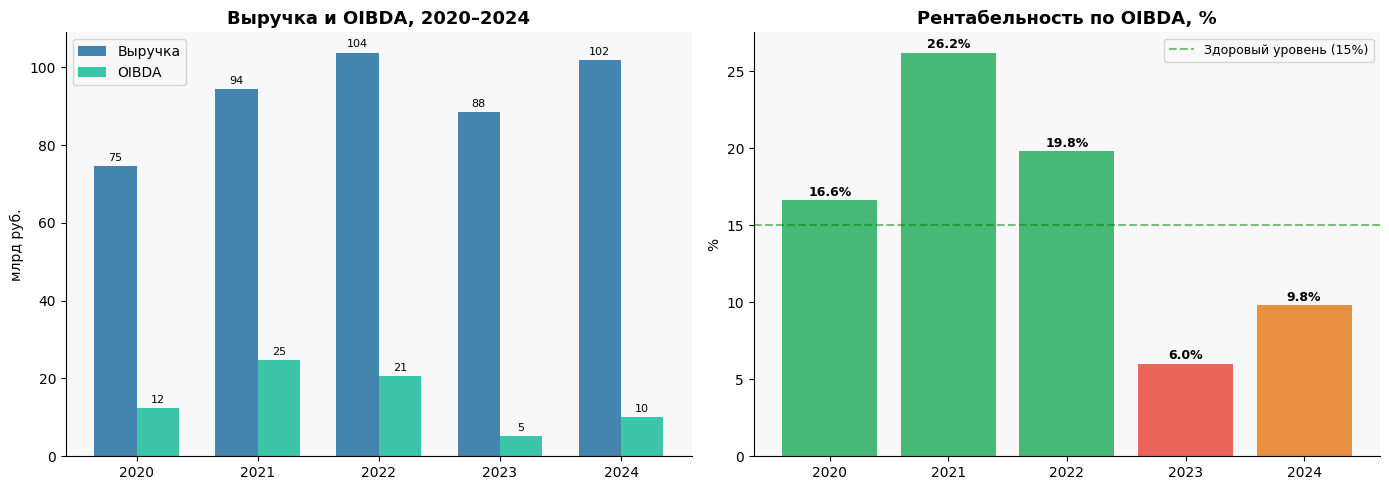

Пик выручки: 2022 (103,8 млрд руб.), но рентабельность по OIBDA рухнула с 19,8% до 5,1%
Пиковая рентабельность 2021: 26,2% (лучший показатель до IPO). Восстановление после санкций пока слабое.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_w = 0.35
x = np.arange(len(years))

ax = axes[0]
b1 = ax.bar(x - bar_w/2, revenue, bar_w, label='Выручка', color='#2471A3', alpha=0.85)
b2 = ax.bar(x + bar_w/2, oibda,   bar_w, label='OIBDA',   color='#1ABC9C', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_ylabel('млрд руб.'); ax.set_title('Выручка и OIBDA, 2020–2024'); ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

margins = [round(o/r*100,1) for o,r in zip(oibda,revenue)]
ax2 = axes[1]
cols = ['#27AE60' if v>=15 else '#E67E22' if v>=8 else '#E74C3C' for v in margins]
ax2.bar(years, margins, color=cols, alpha=0.85)
ax2.axhline(15, color='green', linestyle='--', alpha=0.5, label='Здоровый уровень (15%)')
ax2.set_ylabel('%'); ax2.set_title('Рентабельность по OIBDA, %'); ax2.legend(fontsize=9)
for y, v in zip(years, margins):
    ax2.text(y, v+0.3, f'{v}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('segezha_revenue_oibda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Пик выручки: 2022 (103,8 млрд руб.), но рентабельность по OIBDA рухнула с 19,8% до 5,1%')
print('Пиковая рентабельность 2021: 26,2% (лучший показатель до IPO). Восстановление после санкций пока слабое.')

## 3. Долговая нагрузка — ключевая проблема

Главный риск: **чистый долг растёт быстрее, чем OIBDA**. Показатель «Чистый долг/OIBDA» отражает способность обслуживать долг за счёт операционного денежного потока. 

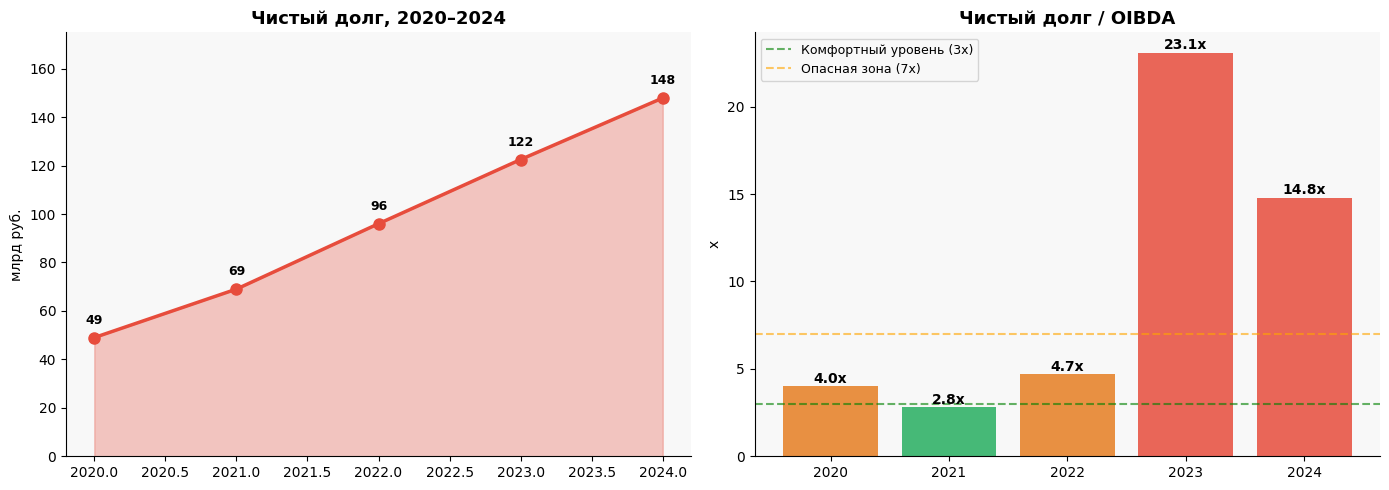

Чистый долг/OIBDA = 14,8x на конец 2024 — КРИТИЧЕСКИЙ УРОВЕНЬ.
OIBDA (10 млрд) не покрывает процентные расходы (~20–22 млрд/год).
В 2025 году допэмиссия акций на ~100 млрд руб. была направлена на частичное погашение долга.


In [4]:
nd_oibda = [round(d/o,1) for d,o in zip(net_debt, oibda)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(years, net_debt, alpha=0.3, color='#E74C3C')
ax.plot(years, net_debt, marker='o', color='#E74C3C', linewidth=2.5, markersize=8)
for y, v in zip(years, net_debt):
    ax.annotate(f'{v:.0f}', (y,v), textcoords='offset points', xytext=(0,10),
                ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('млрд руб.'); ax.set_title('Чистый долг, 2020–2024'); ax.set_ylim(0, 175)

ax2 = axes[1]
nd_cols = ['#27AE60' if v<=3 else '#E67E22' if v<=7 else '#E74C3C' for v in nd_oibda]
bars = ax2.bar(years, nd_oibda, color=nd_cols, alpha=0.85)
ax2.axhline(3, color='green',  linestyle='--', alpha=0.6, label='Комфортный уровень (3x)')
ax2.axhline(7, color='orange', linestyle='--', alpha=0.6, label='Опасная зона (7x)')
for bar, v in zip(bars, nd_oibda):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}x',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('x'); ax2.set_title('Чистый долг / OIBDA'); ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('segezha_debt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Чистый долг/OIBDA = 14,8x на конец 2024 — КРИТИЧЕСКИЙ УРОВЕНЬ.')
print('OIBDA (10 млрд) не покрывает процентные расходы (~20–22 млрд/год).')
print('В 2025 году допэмиссия акций на ~100 млрд руб. была направлена на частичное погашение долга.')

## 4. Котировки акций: История стоимости

Цена IPO составляла 8 руб./акцию (апрель 2021). К концу 2024 года акции потеряли ~81% стоимости. Это наглядно показывает, как операционный кризис превращается в разрушение рыночной капитализации.

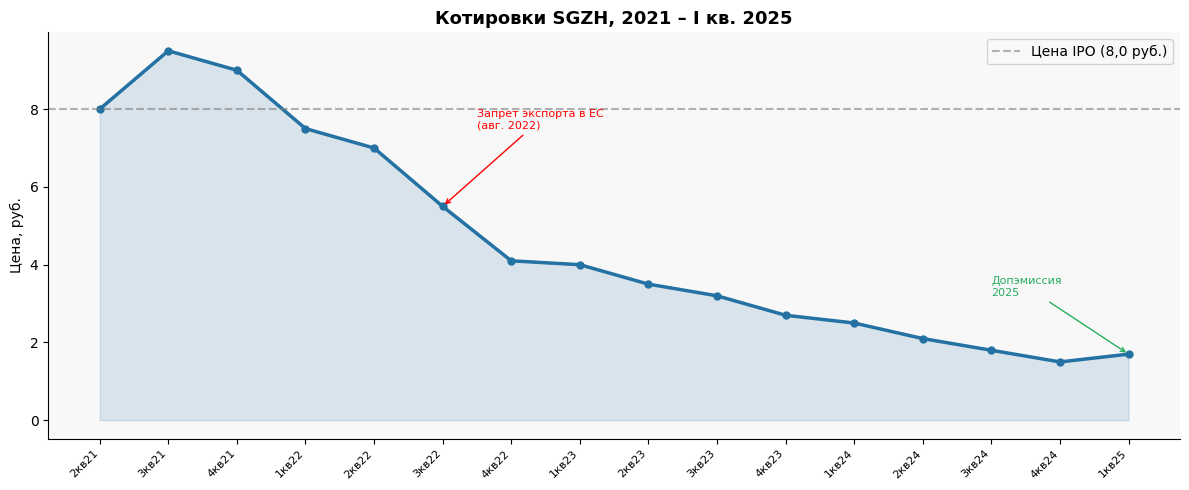

Разрушение стоимости с IPO до IV кв. 2024: -81%  (8,0 -> 1,5 руб.)
Пиковая капитализация (2021): ~115 млрд руб. | Дно (2024): ~21 млрд руб. Против долга: 148 млрд


In [6]:
q_dates = [
    '2кв21','3кв21','4кв21',
    '1кв22','2кв22','3кв22','4кв22',
    '1кв23','2кв23','3кв23','4кв23',
    '1кв24','2кв24','3кв24','4кв24',
    '1кв25',
]
prices = [8.0, 9.5, 9.0, 7.5, 7.0, 5.5, 4.1,
          4.0, 3.5, 3.2, 2.7, 2.5, 2.1, 1.8, 1.5, 1.7]

fig, ax = plt.subplots(figsize=(12, 5))
xr = range(len(q_dates))
ax.plot(xr, prices, marker='o', linewidth=2.5, color='#2471A3', markersize=5)
ax.fill_between(xr, prices, alpha=0.15, color='#2471A3')
ax.axhline(8.0, color='gray', linestyle='--', alpha=0.6, label='Цена IPO (8,0 руб.)')
ax.set_xticks(list(xr)); ax.set_xticklabels(q_dates, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Цена, руб.'); ax.set_title('Котировки SGZH, 2021 – I кв. 2025')
ax.legend()

ax.annotate('Запрет экспорта в ЕС\n(авг. 2022)',
            xy=(5, 5.5), xytext=(5.5, 7.5),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')
ax.annotate('Допэмиссия\n2025',
            xy=(15, 1.7), xytext=(13, 3.2),
            arrowprops=dict(arrowstyle='->', color='#27AE60'), fontsize=8, color='#27AE60')

plt.tight_layout()
plt.savefig('segezha_stock.png', dpi=150, bbox_inches='tight')
plt.show()
print('Разрушение стоимости с IPO до IV кв. 2024: -81%  (8,0 -> 1,5 руб.)')
print('Пиковая капитализация (2021): ~115 млрд руб. | Дно (2024): ~21 млрд руб. Против долга: 148 млрд')

## 5. Структура выручки: разворот на Восток

Важнейший структурный сдвиг Segezha — переориентация экспорта из Европы в Азию и страны MENA. Это напрямую бьёт по марже: азиатские рынки дают более низкие цены реализации пиломатериалы: 168 USD / м³ в 2024 против пикового 284 USD / м³ в 2021).

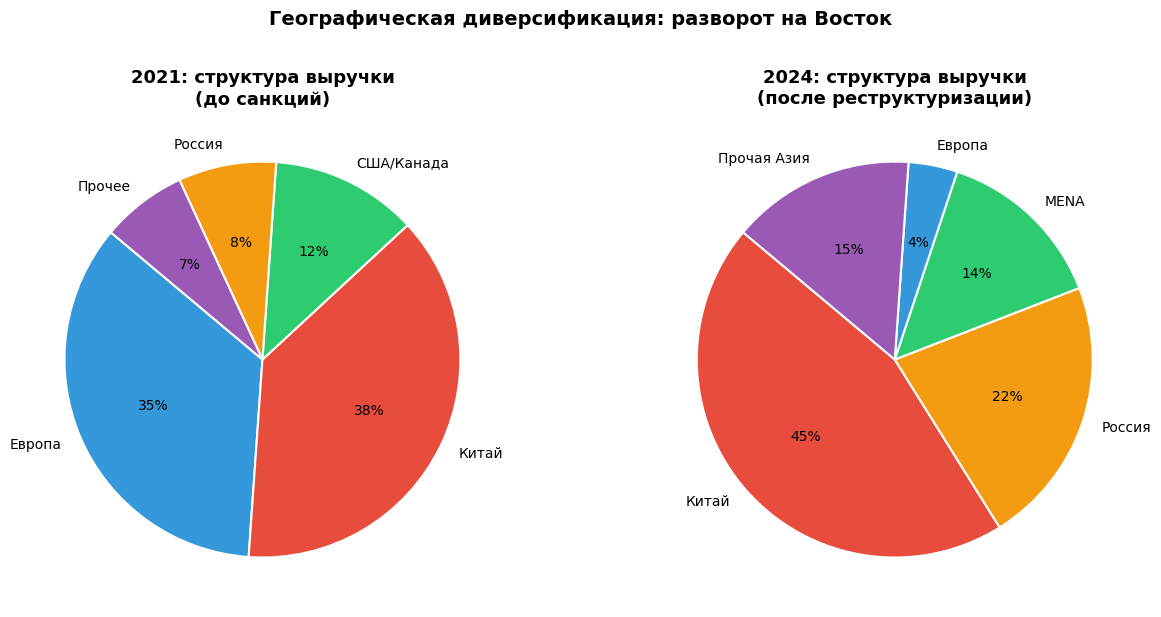

Доля Европы: 35% (2021) -> 4% (2024). Высокомаржинальный рынок утрачен после запрета ЕС в авг. 2022.
Китай компенсировал объёмом, но цены упали: $284/м³ (2021) -> $168/м³ (2024).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colors_geo = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']

axes[0].pie([35,38,12,8,7],
            labels=['Европа','Китай','США/Канада','Россия','Прочее'],
            autopct='%1.0f%%', colors=colors_geo, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('2021: структура выручки\n(до санкций)')

axes[1].pie([45,22,14,4,15],
            labels=['Китай','Россия','MENA','Европа','Прочая Азия'],
            autopct='%1.0f%%',
            colors=['#E74C3C','#F39C12','#2ECC71','#3498DB','#9B59B6'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('2024: структура выручки\n(после реструктуризации)')

plt.suptitle('Географическая диверсификация: разворот на Восток', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segezha_geo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Доля Европы: 35% (2021) -> 4% (2024). Высокомаржинальный рынок утрачен после запрета ЕС в авг. 2022.')
print('Китай компенсировал объёмом, но цены упали: $284/м³ (2021) -> $168/м³ (2024).')

## 6. Сравнение с конкурентами

Сравнение Segezha с мировыми лесопромышленными компаниями по ключевым метрикам 2024 года.

         Компания         Страна  Рентаб. OIBDA %  Чистый долг/EBITDA  Прибыльна
   Segezha (SGZH)         Россия              9.8                14.8      False
            Mondi Великобритания             22.0                 1.8       True
       Stora Enso      Финляндия             18.0                 2.1       True
              UPM      Финляндия             19.0                 1.5       True
Inarcticka (AQUA)         Россия             37.0                 0.3       True


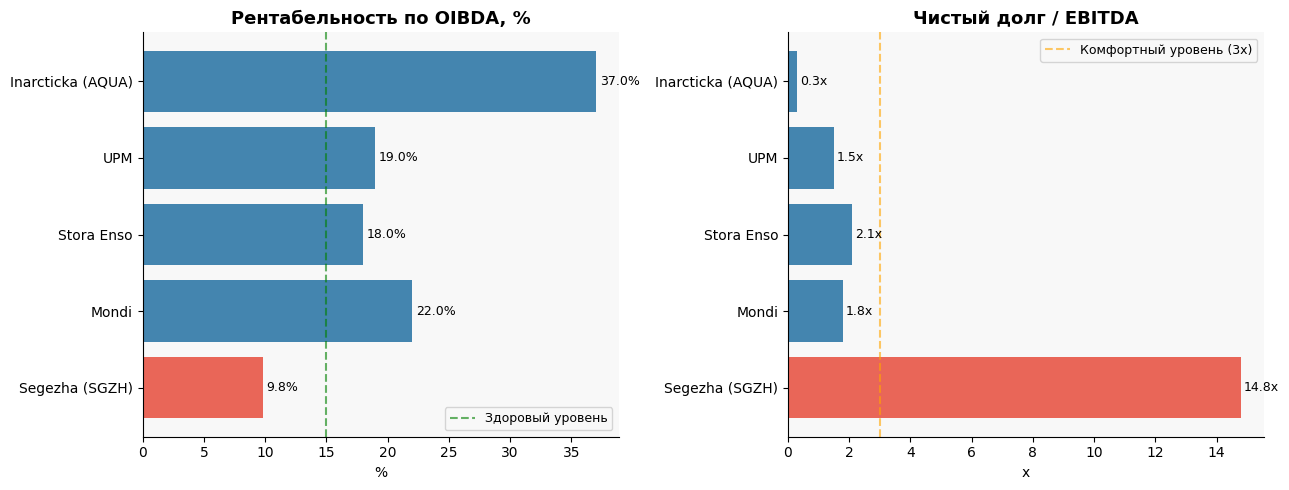

In [9]:
peers = pd.DataFrame({
    'Компания'           : ['Segezha (SGZH)','Mondi','Stora Enso','UPM','Inarcticka (AQUA)'],
    'Страна'             : ['Россия','Великобритания','Финляндия','Финляндия','Россия'],
    'Рентаб. OIBDA %'    : [9.8, 22.0, 18.0, 19.0, 37.0],
    'Чистый долг/EBITDA' : [14.8, 1.8, 2.1, 1.5, 0.3],
    'Прибыльна'          : [False, True, True, True, True],
})

print(peers.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ['#E74C3C' if c=='Segezha (SGZH)' else '#2471A3' for c in peers['Компания']]

axes[0].barh(peers['Компания'], peers['Рентаб. OIBDA %'], color=bar_colors, alpha=0.85)
axes[0].axvline(15, color='green', linestyle='--', alpha=0.6, label='Здоровый уровень')
axes[0].set_xlabel('%'); axes[0].set_title('Рентабельность по OIBDA, %'); axes[0].legend(fontsize=9)
for i,v in enumerate(peers['Рентаб. OIBDA %']):
    axes[0].text(v+0.3, i, f'{v}%', va='center', fontsize=9)

axes[1].barh(peers['Компания'], peers['Чистый долг/EBITDA'], color=bar_colors, alpha=0.85)
axes[1].axvline(3, color='orange', linestyle='--', alpha=0.6, label='Комфортный уровень (3x)')
axes[1].set_xlabel('x'); axes[1].set_title('Чистый долг / EBITDA'); axes[1].legend(fontsize=9)
for i,v in enumerate(peers['Чистый долг/EBITDA']):
    axes[1].text(v+0.1, i, f'{v}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('segezha_peers.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Выводы


1. Критическая долговая нагрузка – чистый долг вырос до 147,9 млрд руб. (2024), соотношение Чистый долг/OIBDA достигло 14,8× при безопасном уровне <3–4×. OIBDA (10 млрд руб.) не покрывает даже годовые процентные расходы (20–22 млрд руб.).

2. Обвал рентабельности – после пика 26,2% в 2021 году рентабельность по OIBDA рухнула до 5,3% в 2023-м и лишь немного восстановилась до 9,8% в 2024-м. Причина: потеря европейского рынка (доля упала с 35% до 4%) и снижение цен реализации в Азии.

3. Разрушение акционерной стоимости – с момента IPO (апрель 2021, 8 руб./акцию) акции потеряли более 80% капитализации к концу 2024 года (1,5 руб./акцию). Рыночная стоимость упала с ~115 млрд руб. до ~21 млрд руб. при долге 148 млрд руб.

4. Структурный сдвиг в выручке – компания переориентировала экспорт с Европы на Китай (45% выручки), MENA и Азию. Цены на пиломатериалы упали с 284 USD /м³ (2021) до 168 USD /м³ (2024), что сжало маржу.

5. Сравнение с конкурентами – Segezha уступает как мировым (Mondi, Stora Enso, UPM), так и российским (Inarcticka) по всем ключевым метрикам: низкая рентабельность, катастрофический долг, отрицательная чистая прибыль.


6. Ключевые точки для улучшения – допэмиссия 2025 года (~100 млрд руб.) направлена на погашение долга, но ставка ЦБ остаётся высокой. Перспективы связаны с рынками MENA, ЮВА.